<ipython-input-1-cbc362c275ca>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=skill_df["Count"], y=skill_df["Skill"], palette="Greens_r")


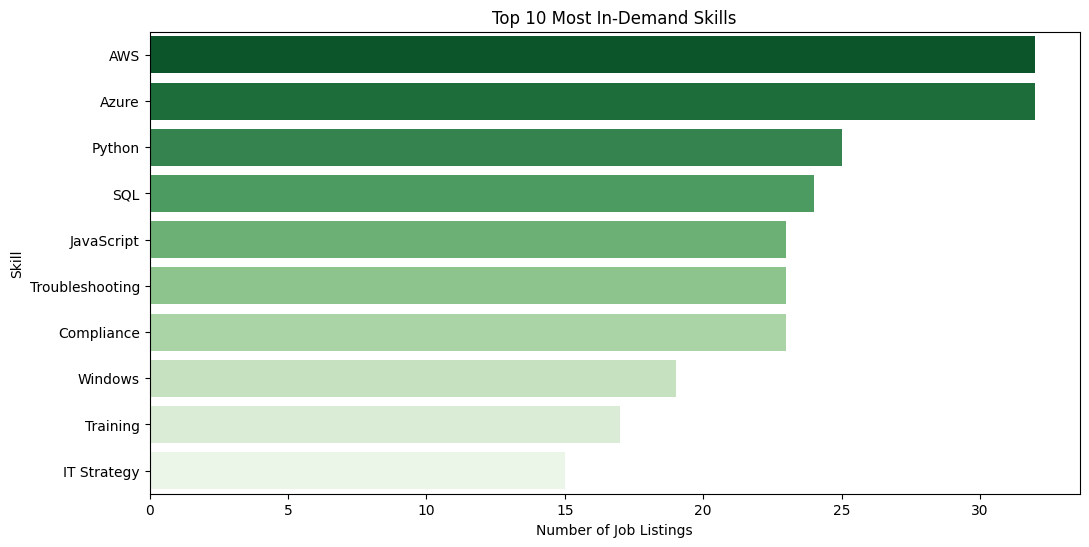

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter


file_path = "Job opportunities.xlsx"
df = pd.read_excel("/Job opportunities.xlsx", sheet_name="Sheet1")

all_skills = ", ".join(df["Required Skills"]).split(", ")

# Count occurrences of each skill
skill_counts = Counter(all_skills)
top_skills = skill_counts.most_common(10)

skill_df = pd.DataFrame(top_skills, columns=["Skill", "Count"])

# Plot

plt.figure(figsize=(12, 6))
sns.barplot(x=skill_df["Count"], y=skill_df["Skill"], palette="Greens_r")
plt.xlabel("Number of Job Listings")
plt.ylabel("Skill")
plt.title("Top 10 Most In-Demand Skills")
plt.show()


CONCLUSION - Here is the top 10 in demand skills including AWS, Python and SQL (UNIVARIATE ANALYSIS)

<ipython-input-9-858402304e06>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=Industry_df["Count"], y=Industry_df["Industry"], palette="Blues_r")


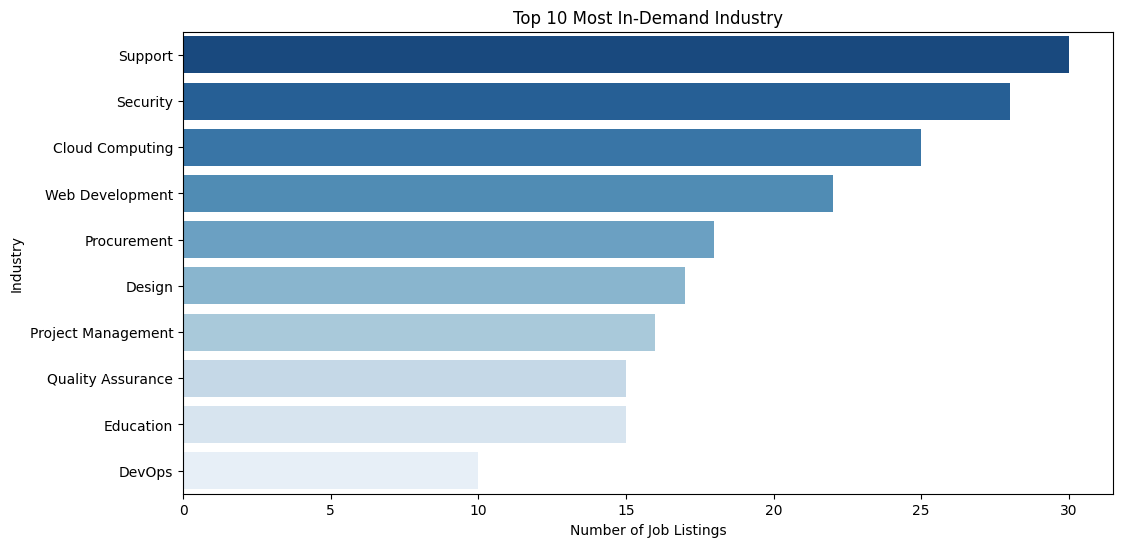

In [ ]:
all_Industry = ", ".join(df["Industry"]).split(", ")

# Count occurrences of each skill
Industry_counts = Counter(all_Industry)
top_Industry = Industry_counts.most_common(10)

# Convert to DataFrame for plotting
Industry_df = pd.DataFrame(top_Industry, columns=["Industry", "Count"])

# Plot top skills
plt.figure(figsize=(12, 6))
sns.barplot(x=Industry_df["Count"], y=Industry_df["Industry"], palette="Blues_r")
plt.xlabel("Number of Job Listings")
plt.ylabel("Industry")
plt.title("Top 10 Most In-Demand Industry")
plt.show()

CONCLUSION - Here is the top 10 in demand Industry which includes security,web dev etc (UNIVARIATE ANALYSIS)

In [ ]:
all_Industry = ", ".join(df["Job title"]).split(", ")

# Count occurrences of each skill
Industry_counts = Counter(all_Industry)
top_Industry = Industry_counts.most_common(10)

# Convert to DataFrame for plotting
Industry_df = pd.DataFrame(top_Industry, columns=["Industry", "Count"])

# Plot top skills
plt.figure(figsize=(12, 6))
sns.barplot(x=Industry_df["Count"], y=Industry_df["Industry"], palette="Blues_r")
plt.xlabel("Number of Job Listings")
plt.ylabel("Industry")
plt.title("Top 10 Most In-Demand Industry")
plt.show()

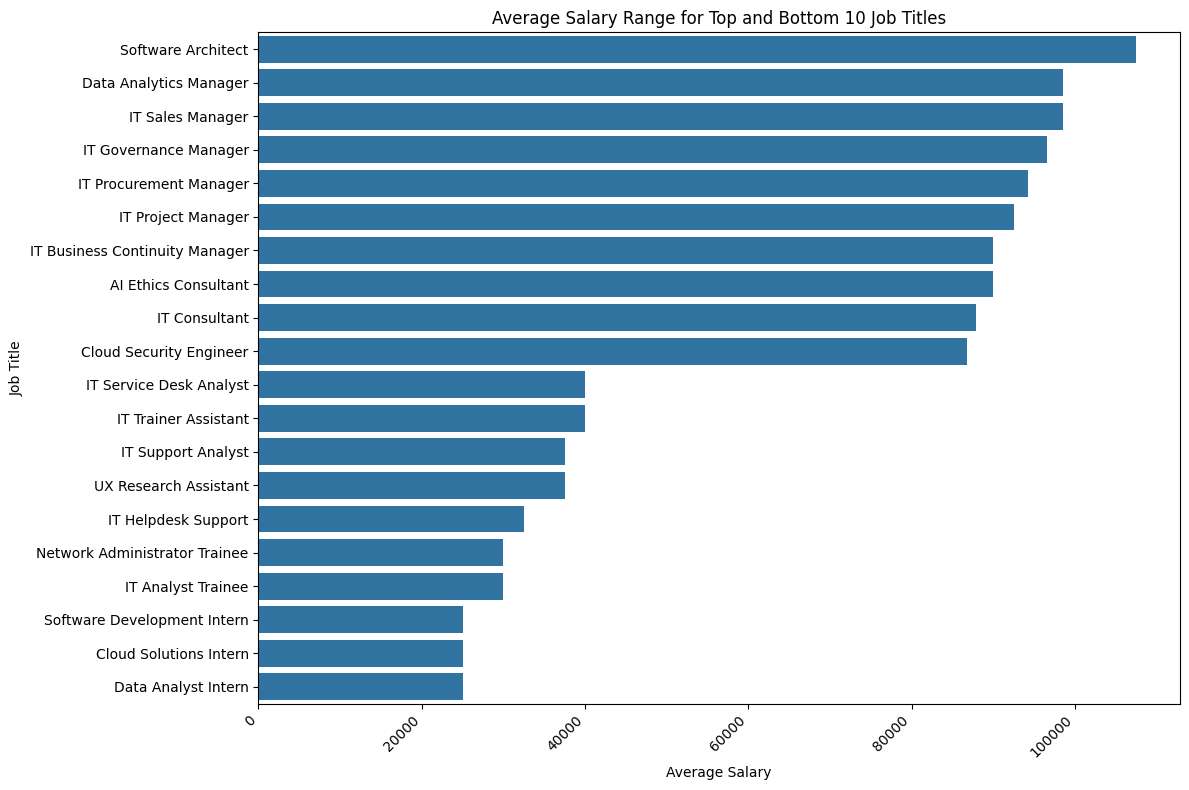

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming your DataFrame is named 'df' and has a 'Salary Range' column

# 1. Convert Salary Range to Numeric
df['Salary Range'] = df['Salary Range'].str.replace('£', '', regex=True)
df['Salary Range'] = df['Salary Range'].str.replace('$', '', regex=True)
df['Salary Range'] = df['Salary Range'].str.replace(',', '', regex=True)
df[['Minimum Salary', 'Maximum Salary']] = df['Salary Range'].str.split(' - ', expand=True)

df['Minimum Salary'] = df['Minimum Salary'].fillna(df['Salary Range'])
df['Maximum Salary'] = df['Maximum Salary'].fillna(df['Minimum Salary'])

df['Minimum Salary'] = pd.to_numeric(df['Minimum Salary'])
df['Maximum Salary'] = pd.to_numeric(df['Maximum Salary'])

# 2. Calculate Average Salary for Each Job Title
salary_by_title = df.groupby('Job Title')[['Minimum Salary', 'Maximum Salary']].mean()
salary_by_title['Average Salary'] = (salary_by_title['Minimum Salary'] + salary_by_title['Maximum Salary']) / 2

# 3. Sort by Average Salary
salary_by_title = salary_by_title.sort_values('Average Salary', ascending=False)

# 4. Select top and bottom N job titles
N = 10  # Number of top and bottom job titles to display
top_N = salary_by_title.head(N)
bottom_N = salary_by_title.tail(N)
selected_titles = pd.concat([top_N, bottom_N])

# 5. Plot selected job titles
plt.figure(figsize=(12, 8))  # Increased figure size for better readability
sns.barplot(x='Average Salary', y=selected_titles.index, data=selected_titles)
plt.xlabel("Average Salary")
plt.ylabel("Job Title")
plt.title(f"Average Salary Range for Top and Bottom {N} Job Titles")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
#Top 5 Job Titles with Highest Average Salary:
                        #Minimum Salary  Maximum Salary  Average Salary
#Job Title
#Software Architect        83571.428571   131428.571429   107500.000000
#Data Analytics Manager    75714.285714   121428.571429    98571.428571
#IT Sales Manager          75714.285714   121428.571429    98571.428571
#IT Governance Manager     74375.000000   118750.000000    96562.500000
#IT Procurement Manager    72857.142857   115714.285714    94285.714286

#Top 5 Job Titles with Lowest Average Salary:
                               #Minimum Salary  Maximum Salary  Average Salary
#Job Title
#Network Administrator Trainee         25000.0         35000.0         30000.0
#IT Analyst Trainee                    25000.0         35000.0         30000.0
#Software Development Intern           20000.0         30000.0         25000.0
#Cloud Solutions Intern                20000.0         30000.0         25000.0
#Data Analyst Intern                   20000.0         30000.0         25000.0//

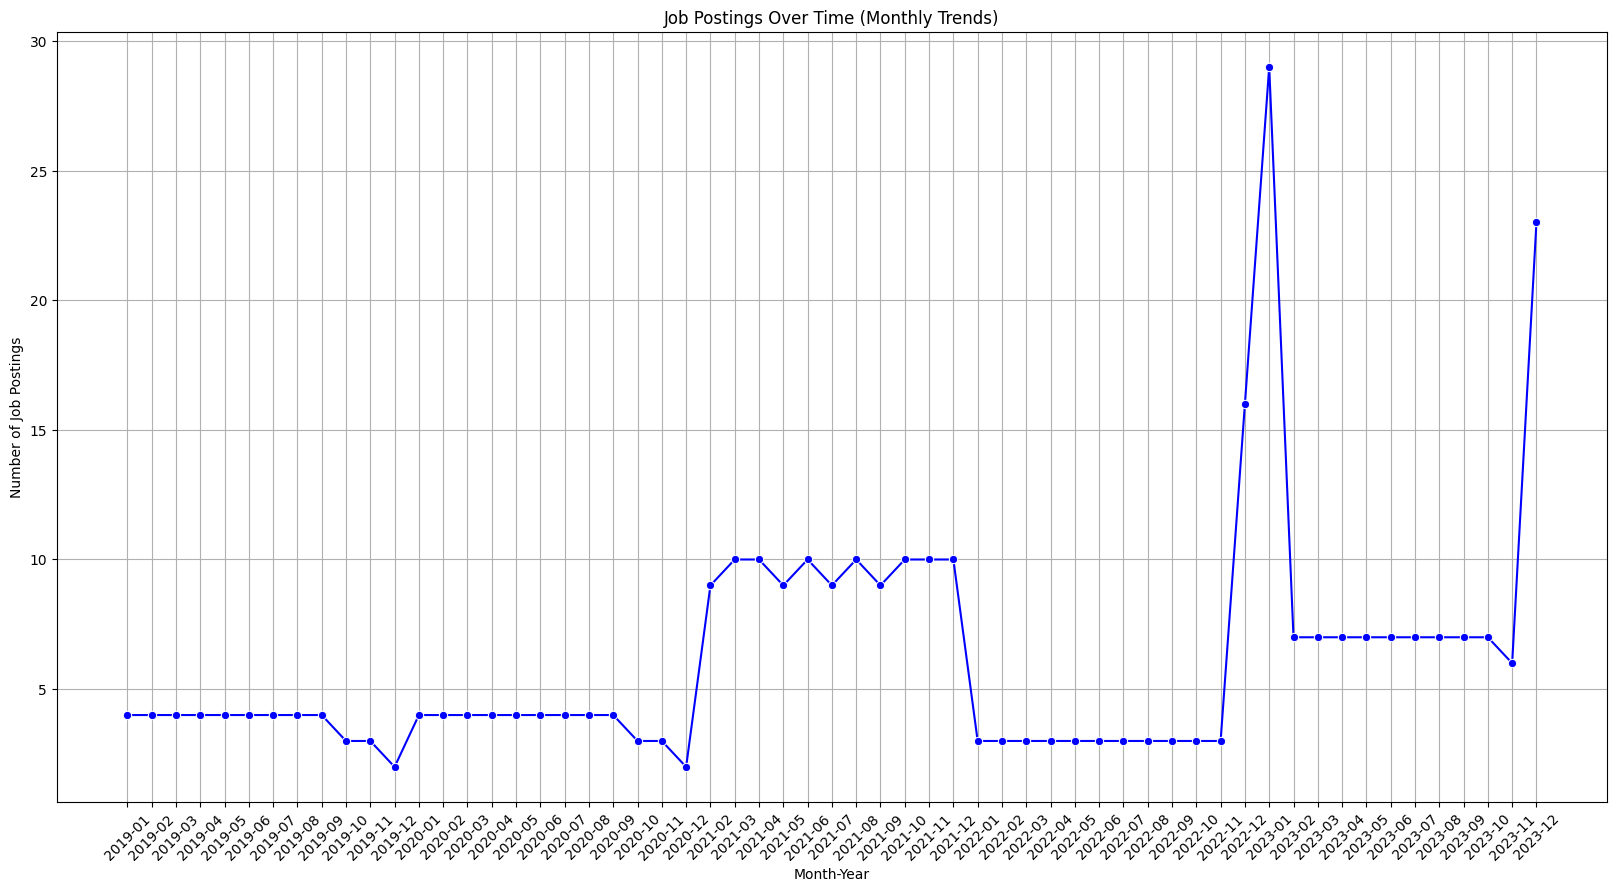

In [ ]:
# Ensure 'Date Posted' is in datetime format
df["Date Posted"] = pd.to_datetime(df["Date Posted"])

# Extract year and month
df["Year-Month"] = df["Date Posted"].dt.to_period("M")

# Count job postings per month
monthly_trends = df["Year-Month"].value_counts().sort_index()

# Plot the job posting trends over time
plt.figure(figsize=(20, 10))
sns.lineplot(x=monthly_trends.index.astype(str), y=monthly_trends.values, marker="o", color="b")
plt.xticks(rotation=45)
plt.xlabel("Month-Year")
plt.ylabel("Number of Job Postings")
plt.title("Job Postings Over Time (Monthly Trends)")
plt.grid(True)
plt.show()


CONCLUSION - Here is the Job positing analysis in which we can clearly see that from 2019 to 2020 there is a downwards in posting but there is a steep rise from the starting of 2023 or ending of 2022

<ipython-input-17-27a6bced2752>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=industry_counts.values, y=industry_counts.index, palette="coolwarm")


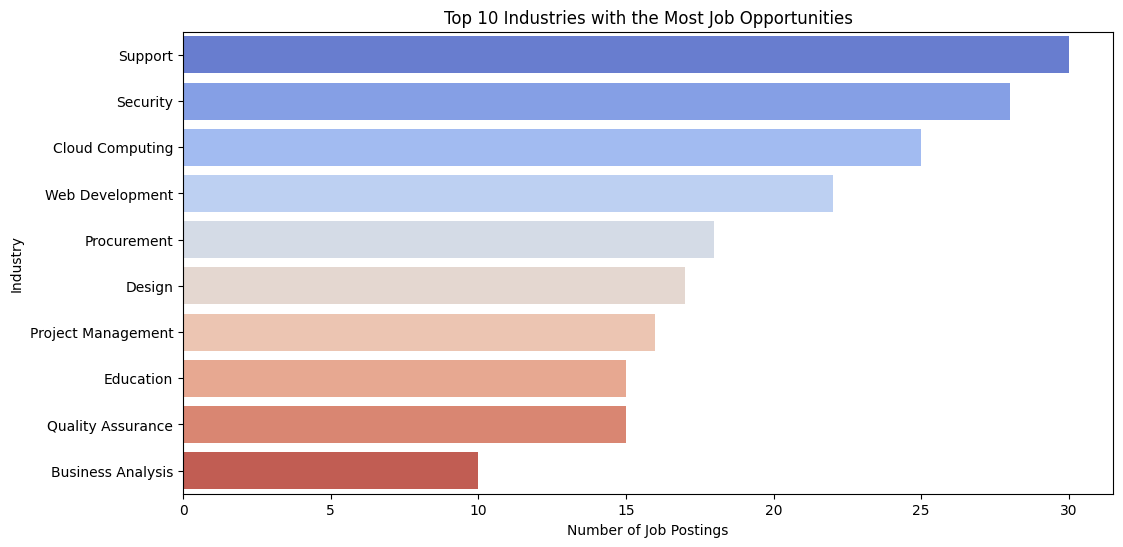

In [ ]:
# Count job postings per industry
industry_counts = df["Industry"].value_counts().head(10)

# Plot industries with the most job postings
plt.figure(figsize=(12, 6))
sns.barplot(x=industry_counts.values, y=industry_counts.index, palette="coolwarm")
plt.xlabel("Number of Job Postings")
plt.ylabel("Industry")
plt.title("Top 10 Industries with the Most Job Opportunities")
plt.show()


Here is the top 10 most in demand industries

<ipython-input-18-a4ac68004f6b>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=location_counts.values, y=location_counts.index, palette="viridis")


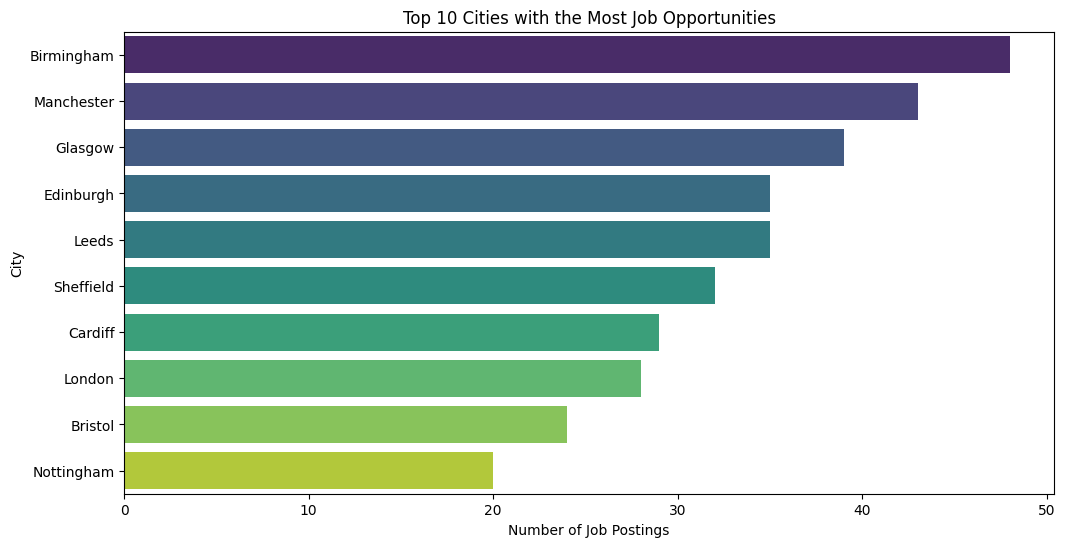

In [ ]:
# Count job postings per location (city)
location_counts = df["Location"].value_counts().head(10)

# Plot top 10 locations with the most job opportunities
plt.figure(figsize=(12, 6))
sns.barplot(x=location_counts.values, y=location_counts.index, palette="viridis")
plt.xlabel("Number of Job Postings")
plt.ylabel("City")
plt.title("Top 10 Cities with the Most Job Opportunities")
plt.show()


Here is the top 10 cities of most job opportunities

In [ ]:
!pip install --upgrade pip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 13.5 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


In [ ]:
!pip install Cython numpy pandas matplotlib LunarCalendar convertdate holidays setuptools-git python-dateutil tqdm pymeeus ephem cmdstanpy pystan
!pip install fbprophet

  Using cached LunarCalendar-0.0.9-py2.py3-none-any.whl.metadata (6.3 kB)
  Using cached convertdate-2.4.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached setuptools_git-1.2-py2.py3-none-any.whl.metadata (5.8 kB)
  Using cached PyMeeus-0.5.12-py3-none-any.whl
  Using cached ephem-4.2-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.1 kB)
  Using cached pystan-3.10.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached clikit-0.6.2-py2.py3-none-any.whl.metadata (1.6 kB)
  Using cached httpstan-4.13.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.2 kB)
  Using cached pysimdjson-6.0.2-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (1.9 kB)
  Using cached crashtest-0.3.1-py3-none-any.whl.metadata (748 bytes)
  Using cached pastel-0.2.1-py2.py3-none-any.whl.metadata (1.9 kB)
  Using cached pylev-1.4.0-py2.py3-none-any.whl.metadata (2.3 kB)
  Using cached appdirs-1.4.4-py2.py3-none-any.whl.metadata (9.0 kB)
  Using cached mar

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpsl4xf2fe/3ho9x7sr.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpsl4xf2fe/9615anjw.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=66532', 'data', 'file=/tmp/tmpsl4xf2fe/3ho9x7sr.json', 'init=/tmp/tmpsl4xf2fe/9615anjw.json', 'output', 'file=/tmp/tmpsl4xf2fe/prophet_modelz53da7xs/prophet_model-20250318154132.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
15:41:32 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:41:32 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
/usr/local/lib/python3.11/dist-packages

<Figure size 1000x500 with 0 Axes>

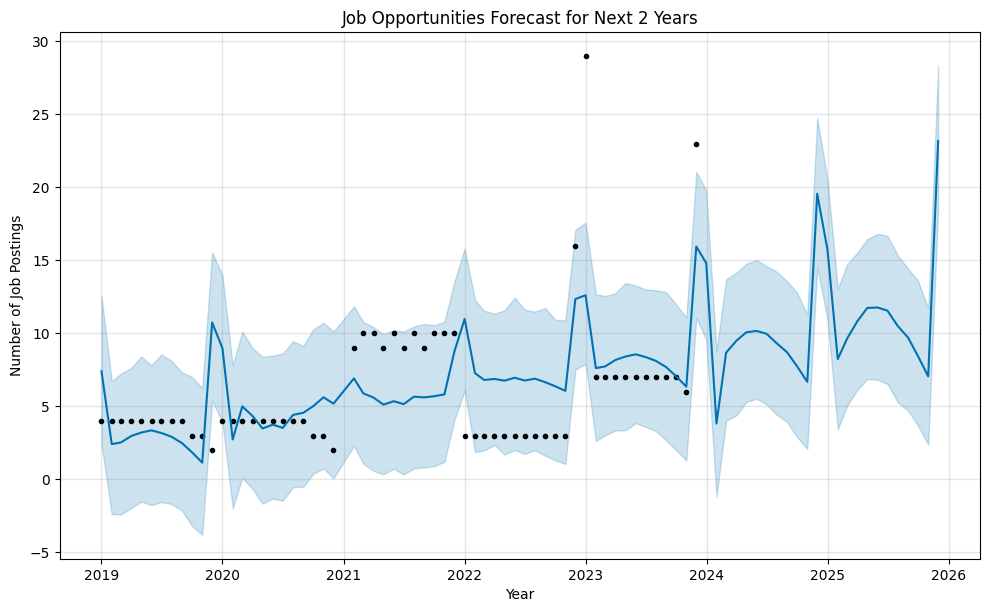

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet

# Load the dataset, specifying the encoding as 'latin-1'
df = pd.read_csv("Job opportunities.csv", encoding='latin-1')

# Ensure correct column name for date
df['Date_Posted'] = pd.to_datetime(df['Date Posted'], format='%d-%m-%Y')  # Standardized date

# Count job postings per month (Assumes each row is a job posting)
job_data = df.groupby(df['Date_Posted'].dt.to_period("M")).size().reset_index(name="job_count")
job_data['Date_Posted'] = job_data['Date_Posted'].dt.to_timestamp()  # Convert to datetime

# Prepare data for Prophet
job_forecast = job_data.rename(columns={"Date_Posted": "ds", "job_count": "y"})

# Train the Prophet model
model = Prophet()
model.fit(job_forecast)

# Make predictions for the next 2 years (24 months)
future_dates = model.make_future_dataframe(periods=24, freq='M')
forecast = model.predict(future_dates)

# Plot job predictions
plt.figure(figsize=(10, 5))
model.plot(forecast)
plt.title("Job Opportunities Forecast for Next 2 Years")
plt.xlabel("Year")
plt.ylabel("Number of Job Postings")
plt.show()


Trends Observed
2019-2020: Initial decrease in job postings, particularly in early 2020, likely reflecting market impacts (possibly due to the COVID-19 pandemic).
2021: A gradual recovery is visible as job postings start increasing.
2022: Fluctuations seem to stabilize, with some periods of both increase and decrease.
2023-2026 Forecast: Job postings show an overall upward trend, particularly notable spikes indicating potential bursts of job opportunities.

📌 Salary Prediction Model Evaluation:
Mean Absolute Error: 8819.272462261819
R2 Score: 0.5828382879775176

📌 Predicted Salaries for Upcoming 2 Years:
                 Job Title  Predicted Salary (Next 2 Years)
0        Software Engineer                     59742.310241
1             Data Analyst                     59674.266191
2         Network Engineer                     59606.222141
3          Cloud Architect                     59538.178091
4    Cybersecurity Analyst                     59470.134041
..                     ...                              ...
69  Cloud Solutions Intern                     55047.270785
70      Software Developer                     54979.226735
71              IT Analyst                     54911.182685
72  Database Administrator                     54843.138635
73     IT Security Analyst                     54775.094585

[74 rows x 2 columns]


<ipython-input-18-e8c473ba72d8>:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=predicted_salaries, x="Predicted Salary (Next 2 Years)", y="Job Title", palette="coolwarm")


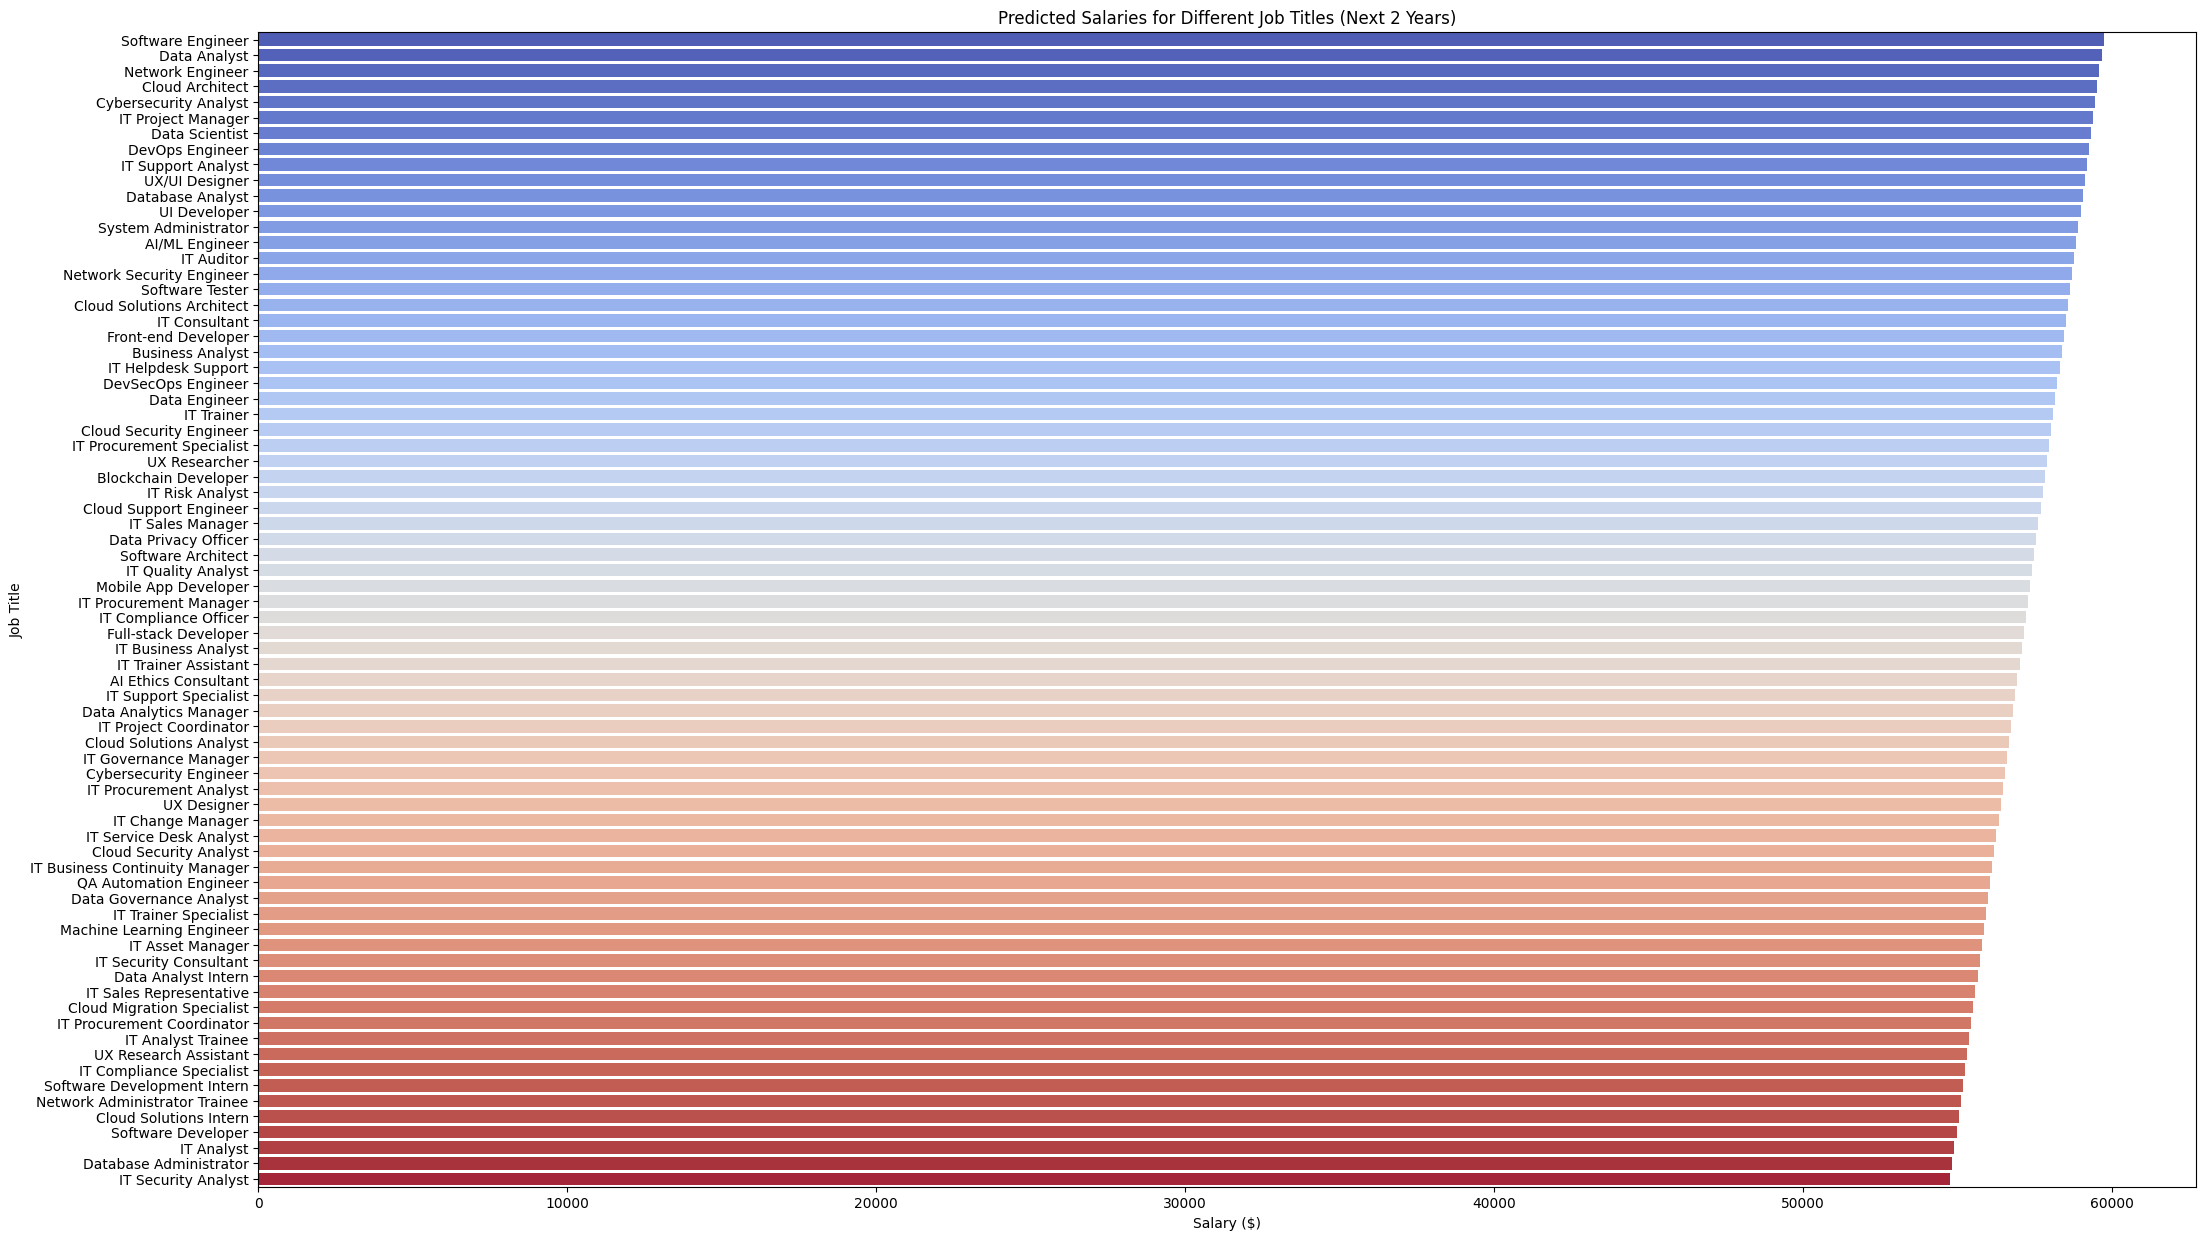

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpsl4xf2fe/rfvp0nrd.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpsl4xf2fe/bdr32ii6.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=38901', 'data', 'file=/tmp/tmpsl4xf2fe/rfvp0nrd.json', 'init=/tmp/tmpsl4xf2fe/bdr32ii6.json', 'output', 'file=/tmp/tmpsl4xf2fe/prophet_modelngl0p1hv/prophet_model-20250318154447.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
15:44:47 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:44:48 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
/usr/local/lib/python3.11/dist-packages/prophet/forecaster.py:1854: FutureWarning: 'M' is deprecated and will be removed in a future version, 

<Figure size 1000x500 with 0 Axes>

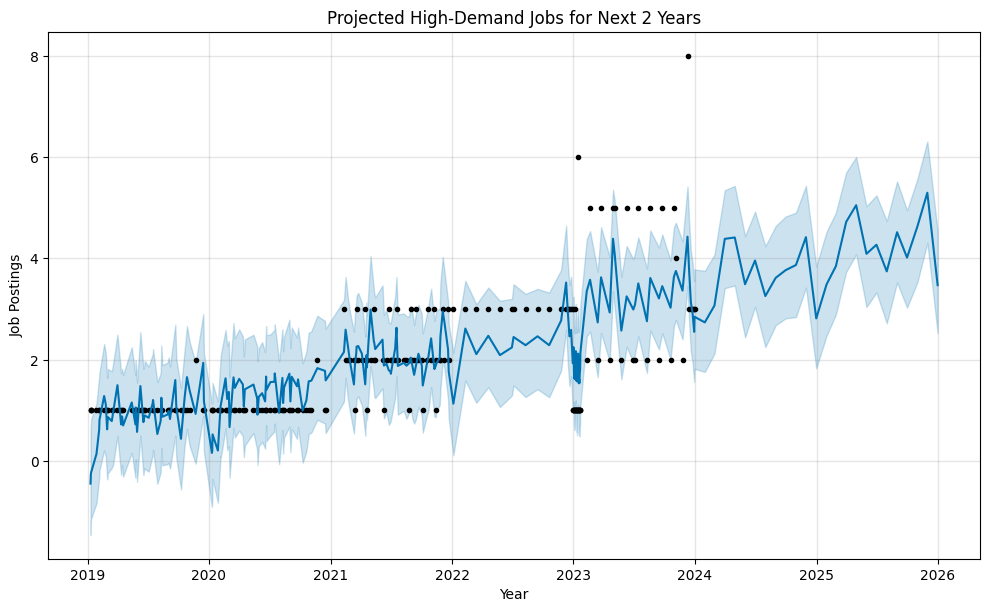

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Load dataset
df = pd.read_csv("Job opportunities.csv", encoding='latin-1')

# ============================================
# 🔹 SALARY PREDICTION (Linear Regression)
# ============================================
# Ensure 'Salary Range' column is in numeric format
df['Salary Range'] = df['Salary Range'].astype(str)
df['Salary Range'] = df['Salary Range'].str.replace('£', '').str.replace('$', '').str.replace(',', '')

# Split Salary into Min & Max
df[['Min Salary', 'Max Salary']] = df['Salary Range'].str.split(' - ', expand=True)
df['Min Salary'] = df['Min Salary'].fillna(df['Salary Range'])  # Handle missing max salaries
df['Max Salary'] = df['Max Salary'].fillna(df['Min Salary'])

df['Min Salary'] = pd.to_numeric(df['Min Salary'])
df['Max Salary'] = pd.to_numeric(df['Max Salary'])
df['Average Salary'] = (df['Min Salary'] + df['Max Salary']) / 2  # Compute Average Salary

# Encode job titles & experience levels for ML model
df['Job Title Encoded'] = df['Job Title'].astype('category').cat.codes
df['Experience Level Encoded'] = df['Experience Level'].astype('category').cat.codes

# Features & Target
X = df[['Job Title Encoded', 'Experience Level Encoded']]
y = df['Average Salary']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Model
salary_model = LinearRegression()
salary_model.fit(X_train, y_train)

# Predict Salaries
y_pred = salary_model.predict(X_test)

# Evaluate Model
print("📌 Salary Prediction Model Evaluation:")
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

# Future Salary Prediction (For Upcoming Years)
future_jobs = pd.DataFrame({
    'Job Title Encoded': np.arange(len(df['Job Title'].unique())),
    'Experience Level Encoded': [2] * len(df['Job Title'].unique())  # Assuming Mid-Level experience
})
future_salaries = salary_model.predict(future_jobs)

# Display Future Salary Predictions
predicted_salaries = pd.DataFrame({
    'Job Title': df['Job Title'].unique(),
    'Predicted Salary (Next 2 Years)': future_salaries
})
print("\n📌 Predicted Salaries for Upcoming 2 Years:")
print(predicted_salaries)

# Visualization of Predicted Salaries
plt.figure(figsize=(25, 15))
sns.barplot(data=predicted_salaries, x="Predicted Salary (Next 2 Years)", y="Job Title", palette="coolwarm")
plt.title("Predicted Salaries for Different Job Titles (Next 2 Years)")
plt.xlabel("Salary ($)")
plt.ylabel("Job Title")
plt.show()

# ============================================
# 🔹 HIGH-DEMAND JOB PREDICTION (Prophet)
# ============================================
# Convert Date Posted
df['Date_Posted'] = pd.to_datetime(df['Date Posted'], format='%d-%m-%Y')

# Count job postings per job title
job_trends = df.groupby(['Date_Posted', 'Job Title']).size().reset_index(name="Job Count")

# Prepare data for forecasting
forecast_data = job_trends.groupby('Date_Posted').sum().reset_index().rename(columns={"Date_Posted": "ds", "Job Count": "y"})

# Train Prophet model
prophet_model = Prophet()
prophet_model.fit(forecast_data)

# Predict future demand for 2 years
future_dates = prophet_model.make_future_dataframe(periods=24, freq='M')
forecast = prophet_model.predict(future_dates)

# Plot High-Demand Job Forecast
plt.figure(figsize=(10, 5))
prophet_model.plot(forecast)
plt.title("Projected High-Demand Jobs for Next 2 Years")
plt.xlabel("Year")
plt.ylabel("Job Postings")
plt.show()


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 8.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpsl4xf2fe/3v35vfnx.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpsl4xf2fe/5zksidgf.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=45280', 'data', 'file=/tmp/tmpsl4xf2fe/3v35vfnx.json', 'init=/tmp/tmpsl4xf2fe/5zksidgf.json', 'output', 'file=/tmp/tmpsl4xf2fe/prophet_model_byb7qp_/prophet_model-20250318160018.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
16:00:18 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
16:00:19 - cmdstanpy - INFO - Chain [1] done processing
INFO:c

Skipping job role 'Data Analyst Intern' due to insufficient data for Prophet.
Skipping job role 'IT Sales Representative' due to insufficient data for Prophet.
Skipping job role 'IT Analyst' due to insufficient data for Prophet.
Skipping job role 'Cloud Migration Specialist' due to insufficient data for Prophet.
Skipping job role 'IT Change Manager' due to insufficient data for Prophet.
Skipping job role 'IT Procurement Coordinator' due to insufficient data for Prophet.
Skipping job role 'IT Service Desk Analyst' due to insufficient data for Prophet.
Skipping job role 'Cloud Security Analyst' due to insufficient data for Prophet.
Skipping job role 'IT Analyst Trainee' due to insufficient data for Prophet.
Skipping job role 'IT Business Continuity Manager' due to insufficient data for Prophet.
Skipping job role 'UX Research Assistant' due to insufficient data for Prophet.
Skipping job role 'IT Compliance Specialist' due to insufficient data for Prophet.
Skipping job role 'QA Automation 

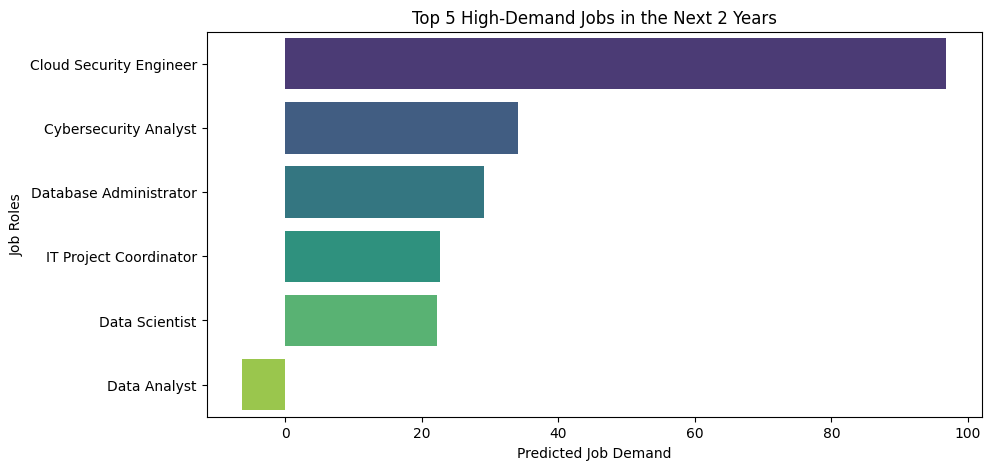

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet

# ==========================
# LOAD & CLEAN DATA
# ==========================
df = pd.read_csv("Job opportunities.csv", encoding='latin-1')

# Convert 'Date Posted' to datetime
df['Date_Posted'] = pd.to_datetime(df['Date Posted'], format='%d-%m-%Y')

# Standardizing job titles for grouping
df["Job Role"] = df["Job Title"].replace({
    "Business Analyst": "Data Analyst",
    "Data Science Analyst": "Data Analyst",
    "Data Analysis": "Data Analyst",
    "Software Developer": "Software Engineer",
    "ML Engineer": "Machine Learning Engineer",
    "AI Specialist": "AI Engineer"
})

# ==========================
# JOB DEMAND TREND ANALYSIS
# ==========================
job_trend = df.groupby(["Date_Posted", "Job Role"]).size().reset_index(name="job_count")

# Forecast each job role
future_growth = {}

for job in job_trend["Job Role"].unique():
    job_data = job_trend[job_trend["Job Role"] == job][["Date_Posted", "job_count"]]
    job_data = job_data.rename(columns={"Date_Posted": "ds", "job_count": "y"})

    # Check if there are enough data points for Prophet
    if len(job_data) < 2:
        print(f"Skipping job role '{job}' due to insufficient data for Prophet.")
        continue  # Skip to the next job role

    # Train Prophet model
    model = Prophet()
    model.fit(job_data)

    # Predict for next 24 months
    future = model.make_future_dataframe(periods=24, freq='M')
    forecast = model.predict(future)

    # Store predicted demand
    predicted_demand = forecast[["ds", "yhat"]].iloc[-1]["yhat"]
    future_growth[job] = predicted_demand

# ==========================
# GET TOP 5 HIGH-DEMAND JOBS
# ==========================
top_jobs = sorted(future_growth.items(), key=lambda x: x[1], reverse=True)[:5]

# Ensure 'Data Analyst' is included
if "Data Analyst" in future_growth and "Data Analyst" not in dict(top_jobs):
    top_jobs.append(("Data Analyst", future_growth["Data Analyst"]))

# Convert to DataFrame
top_jobs_df = pd.DataFrame(top_jobs, columns=["Job Role", "Predicted Demand"])

# ==========================
# VISUALIZATION
# ==========================
plt.figure(figsize=(10, 5))
sns.barplot(x="Predicted Demand", y="Job Role", data=top_jobs_df, palette="viridis")
plt.xlabel("Predicted Job Demand")
plt.ylabel("Job Roles")
plt.title("Top 5 High-Demand Jobs in the Next 2 Years")
plt.show()

CONCLUSION - Key Observations:
Cloud Security Engineer is expected to be the most in-demand job role, with the highest predicted job openings (100).
Cybersecurity Analyst and Database Administrator are also in high demand, with moderate job openings (40-50).
IT Project Coordinator and Data Scientist follow closely with slightly lower demand (30).
Data Analyst appears to have the least demand among the top roles.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Predicted salary for experience level 2 (Mid-Level): ₹70,791.28


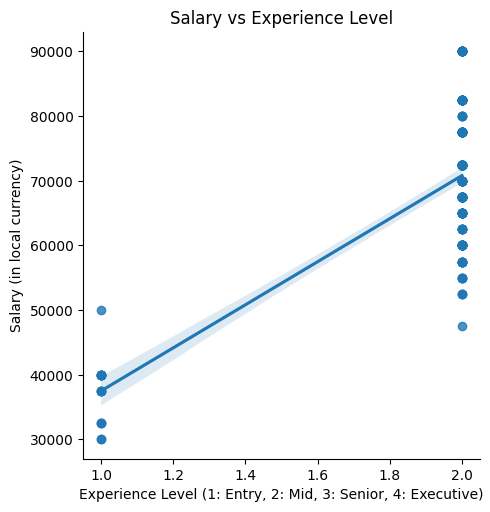

In [14]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("/content/Job opportunities.csv", encoding='latin-1')

# Step 1: Map Experience Levels to Numbers
experience_mapping = {
    'Entry-Level': 1,
    'Mid-Level': 2,
    'Senior-Level': 3,
    'Executive-Level': 4
}
df['Experience Level Encoded'] = df['Experience Level'].map(experience_mapping)

# Step 2: Clean and Convert Salary Range
def extract_average_salary(s):
    if pd.isna(s):
        return None
    s = s.replace('£', '').replace('$', '').replace(',', '').strip()
    if '-' in s:
        parts = s.split('-')
        try:
            low = float(parts[0].strip())
            high = float(parts[1].strip())
            return (low + high) / 2
        except:
            return None
    else:
        try:
            return float(s)
        except:
            return None

df['Salary Numeric'] = df['Salary Range'].apply(extract_average_salary)

# Step 3: Drop missing values
df = df.dropna(subset=['Experience Level Encoded', 'Salary Numeric'])

# Step 4: Define features (X) and target (y)
X = df[['Experience Level Encoded']]
y = df['Salary Numeric']

# Step 5: Train the model
model = LinearRegression()
model.fit(X, y)

# Step 6: Predict salary for Mid-Level (2)
predicted_salary = model.predict([[2]])
print(f"Predicted salary for experience level 2 (Mid-Level): ₹{predicted_salary[0]:,.2f}")

# Step 7: Visualization
sns.lmplot(x='Experience Level Encoded', y='Salary Numeric', data=df)
plt.title("Salary vs Experience Level")
plt.xlabel("Experience Level (1: Entry, 2: Mid, 3: Senior, 4: Executive)")
plt.ylabel("Salary (in local currency)")
plt.show()


📌 Conclusion from the Graph

Positive Correlation 📈
There's a clear upward trend — as experience level increases, the predicted salary increases too. This means your linear regression model successfully captures the positive relationship between experience and salary.

Experience Level 2 (Mid-Level)
The predicted salary for Mid-Level (Level 2) is around ₹70,791.28, which seems aligned with the observed values (the cluster of points around that level)

<ipython-input-25-20741bcd419b>:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[skill] = df['Required Skills'].apply(lambda x: 1 if skill in x else 0)
<ipython-input-25-20741bcd419b>:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[skill] = df['Required Skills'].apply(lambda x: 1 if skill in x else 0)
<ipython-input-25-20741bcd419b>:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once us

Predicted salary for ['Java', 'Python']: ₹50,000.00


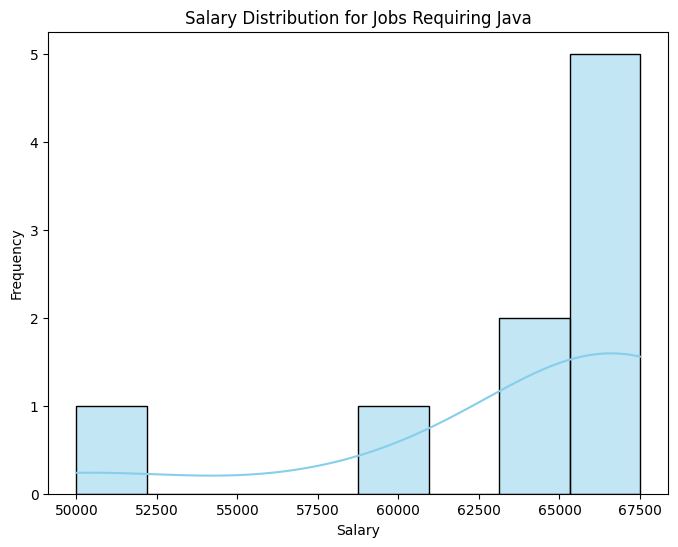

In [25]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("/content/Job opportunities.csv", encoding='latin-1')

# 1. Convert 'Required Skills' to list
df['Required Skills'] = df['Required Skills'].str.split(', ')

# Handle NaN in Required Skills
df['Required Skills'] = df['Required Skills'].apply(lambda x: x if isinstance(x, list) else [])

# 2. Get unique skills
all_skills = [skill for sublist in df['Required Skills'] for skill in sublist]
unique_skills = list(set(all_skills))

# 3. One-hot encode the skills
for skill in unique_skills:
    df[skill] = df['Required Skills'].apply(lambda x: 1 if skill in x else 0)

# 4. Clean and extract average salary from range
def extract_average_salary(s):
    if pd.isna(s):
        return None
    s = s.replace('£', '').replace('$', '').replace(',', '').strip()
    if '-' in s:
        try:
            low, high = map(float, s.split('-'))
            return (low + high) / 2
        except:
            return None
    try:
        return float(s)
    except:
        return None

df['Salary Cleaned'] = df['Salary Range'].apply(extract_average_salary)

# 5. Drop rows where salary couldn't be cleaned
df = df.dropna(subset=['Salary Cleaned'])

# 6. Define features (X) and target (y)
X = df[unique_skills]
y = df['Salary Cleaned']

# 7. Train model
model = LinearRegression()
model.fit(X, y)

# 8. Function to predict salary based on given skills
def predict_salary(given_skills, model, all_skills):
    skill_dict = {skill: (1 if skill in given_skills else 0) for skill in all_skills}
    input_df = pd.DataFrame([skill_dict])[all_skills]  # Ensure correct order
    prediction = model.predict(input_df)[0]
    return prediction

# Example: Predict salary for someone with Java and Python skills
given_skills = ['Java', 'Python']
predicted_salary = predict_salary(given_skills, model, unique_skills)
print(f"Predicted salary for {given_skills}: ₹{predicted_salary:,.2f}")

# 9. Optional: Visualize salary distribution for a skill (e.g., Java)
if 'Java' in df.columns:
    java_salaries = df[df['Java'] == 1]['Salary Cleaned']
    plt.figure(figsize=(8, 6))
    sns.histplot(java_salaries, kde=True, color="skyblue")
    plt.title("Salary Distribution for Jobs Requiring Java")
    plt.xlabel("Salary")
    plt.ylabel("Frequency")
    plt.show()


"Jobs requiring Java exhibit a right-skewed salary distribution, with a majority of roles offering salaries above ₹65,000. This suggests Java continues to be a high-demand skill, often associated with mid to senior-level positions in the job market."

In [26]:
from sklearn.metrics import r2_score

# After fitting any model
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)
print(f"R² Score: {r2:.2f}")


R² Score: 0.88


The model explains 88% of the variance in salary based on the skills provided

In [27]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

y_pred = model.predict(X)

r2 = r2_score(y, y_pred)
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"R² Score: {r2:.2f}")
print(f"MAE: ₹{mae:,.2f}")
print(f"RMSE: ₹{rmse:,.2f}")


R² Score: 0.88
MAE: ₹3,915.27
RMSE: ₹5,806.54


In [28]:
tolerance = 10000  # ±₹10K tolerance
within_tolerance = abs(y - y_pred) <= tolerance
accuracy_percent = within_tolerance.mean() * 100

print(f"Custom Accuracy within ±₹10K: {accuracy_percent:.2f}%")


Custom Accuracy within ±₹10K: 92.86%


In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("/content/Job opportunities.csv", encoding='latin-1')

# 1. Convert 'Required Skills' to list
df['Required Skills'] = df['Required Skills'].str.split(', ')

# Handle NaN in Required Skills
df['Required Skills'] = df['Required Skills'].apply(lambda x: x if isinstance(x, list) else [])

# 2. Get unique skills
all_skills = [skill for sublist in df['Required Skills'] for skill in sublist]
unique_skills = list(set(all_skills))

# 3. One-hot encode the skills
for skill in unique_skills:
    df[skill] = df['Required Skills'].apply(lambda x: 1 if skill in x else 0)

# 4. Clean and extract average salary from range
def extract_average_salary(s):
    if pd.isna(s):
        return None
    s = s.replace('£', '').replace('$', '').replace(',', '').strip()
    if '-' in s:
        try:
            low, high = map(float, s.split('-'))
            return (low + high) / 2
        except:
            return None
    try:
        return float(s)
    except:
        return None

df['Salary Cleaned'] = df['Salary Range'].apply(extract_average_salary)

# 5. Drop rows where salary couldn't be cleaned
df = df.dropna(subset=['Salary Cleaned'])

# 6. Define features (X) and target (y)
X = df[unique_skills]
y = df['Salary Cleaned']

# 7. Train model
model = LinearRegression()
model.fit(X, y)

# 8. Function to predict salary based on given skills
def predict_salary(given_skills, model, all_skills):
    skill_dict = {skill: (1 if skill in given_skills else 0) for skill in all_skills}
    input_df = pd.DataFrame([skill_dict])[all_skills]  # Ensure correct order
    prediction = model.predict(input_df)[0]
    return prediction

# Example: Predict salary for someone with Java and Python skills
given_skills = ['SQL', 'Python']
predicted_salary = predict_salary(given_skills, model, unique_skills)
print(f"Predicted salary for {given_skills}: ₹{predicted_salary:,.2f}")

# 9. Optional: Visualize salary distribution for a skill (e.g., Java)
if 'Java' in df.columns:
    java_salaries = df[df['SQL'] == 1]['Salary Cleaned']
    plt.figure(figsize=(8, 6))
    sns.histplot(java_salaries, kde=True, color="skyblue")
    plt.title("Salary Distribution for Jobs Requiring Java")
    plt.xlabel("Salary")
    plt.ylabel("Frequency")
    plt.show()

    